<a href="https://colab.research.google.com/github/SousaValentyna/MyMeow2/blob/main/cartpole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Importação das bibliotecas

Neste primeiro bloco, são importadas as bibliotecas necessárias para o desenvolvimento do projeto.

**NumPy**: para cálculos numéricos e manipulação de vetores.

**Matplotlib**: para gerar gráficos das funções de pertinência.

**scikit-fuzzy**: biblioteca responsável pela criação do sistema de controle fuzzy (SCI).

**gymnasium**: fornece o ambiente de simulação CartPole, em que o objetivo é manter o pêndulo (poste) em pé pelo maior número de passos possíveis.

imageio e base64 **negrito**: utilizadas para renderizar o vídeo da simulação dentro do notebook.

In [ ]:
# === INSTALAÇÕES MÍNIMAS (rode no Colab/Jupyter) ===
!pip install -q scikit-fuzzy gymnasium imageio

# === IMPORTS ===
import numpy as np
import imageio, base64
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl, membership as mf
from IPython.display import HTML, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.6 MB/s eta 0:00:00


## Criação do ambiente CartPole

Nesta etapa, o ambiente CartPole é criado utilizando a biblioteca GYM.
O ambiente contém quatro variáveis principais:

Posição do carrinho,

Velocidade linear,

Ângulo do poste,

Velocidade angular.

O objetivo é aplicar uma força de controle (ação) no carrinho para que o poste não caia.
O máximo de passos permitido é 500, e o sistema é considerado bem-sucedido se o poste se mantiver em pé durante todos esses passos.

In [ ]:
# === GYM ===
try:
    import gymnasium as gym
    _usa_gymnasium = True
except Exception:
    import gym
    _usa_gymnasium = False


def criar_ambiente():
    """Cria o ambiente CartPole com renderização RGB (compatível com Gym e Gymnasium)."""
    if _usa_gymnasium:
        return gym.make('CartPole-v1', render_mode='rgb_array')
    else:
        env = gym.make('CartPole-v1')
        return env

##Descrição do Sistema Fuzzy — Definição das Funções de Pertinência e Regras

Esta parte do código define o controlador fuzzy responsável por estabilizar o poste do ambiente CartPole.
Foram utilizadas duas variáveis de entrada — ângulo (ang) e velocidade angular (vel) — e uma variável de saída — força aplicada (act).
Os universos de discurso foram definidos conforme os limites físicos do sistema:

- Ângulo entre −0.25 e +0.25 rad, representando a inclinação máxima do poste.

- Velocidade angular entre −6 e +6 rad/s, cobrindo a faixa de variação antes da queda.

- Força entre −1 e +1, normalizada de acordo com o controle do ambiente GYM.

As funções de pertinência foram ajustadas para aumentar a sensibilidade em torno do equilíbrio (0 rad):

- Para o ângulo e a velocidade angular, foram usados cinco conjuntos fuzzy — muito negativo (mn), negativo (n), zero (z), positivo (p) e muito positivo (mp).
As funções trapezoidais cobrem as regiões extremas (limites de saturação), enquanto as triangulares e a gaussiana central (σ = 0.04 para o ângulo, σ = 1.0 para a velocidade) garantem resposta contínua e precisa próximo ao ponto de equilíbrio.

- A variável de saída (força) também foi dividida em cinco conjuntos — força extrema esquerda (fe), esquerda (e), zero (z), direita (d) e força extrema direita (fd) — permitindo aplicar correções suaves ou intensas conforme a inclinação.

As regras fuzzy foram criadas com base no comportamento físico do sistema:

- Se o poste inclina para a direita (ângulo positivo), aplica-se força à direita (act = d ou fd).

- Se inclina para a esquerda (ângulo negativo), aplica-se força à esquerda (act = e ou fe).

- Quando o ângulo e a velocidade angular são próximos de zero, aplica-se força neutra (act = z), mantendo o equilíbrio.
Regras adicionais combinam ângulo e velocidade para antecipar correções, evitando overshoot e estabilizando o poste mesmo durante variações rápidas.

Essas faixas e regras foram testadas experimentalmente até que o sistema alcançasse estabilidade total, mantendo o poste equilibrado durante os 500 passos da simulação sem oscilações bruscas.

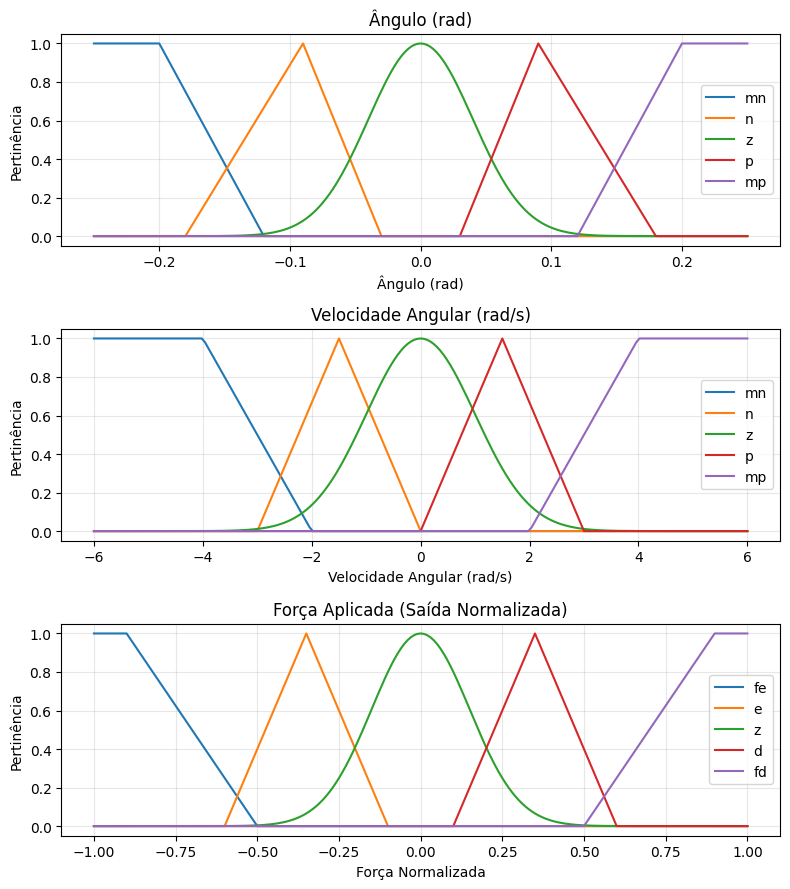

Sucesso: completou os 500 passos sem cair!


In [ ]:
# fuzzy
def construir_controlador():
    # Universos coerentes com o CartPole
    u_ang = np.linspace(-0.25, 0.25, 201, dtype=float)   # rad
    u_vel_ang = np.linspace(-6.0, 6.0, 201, dtype=float) # rad/s
    u_acao = np.linspace(-1.0, 1.0, 201, dtype=float)    # força normalizada

    ang = ctrl.Antecedent(u_ang, 'ang')
    vel = ctrl.Antecedent(u_vel_ang, 'vel')
    act = ctrl.Consequent(u_acao, 'act')

    # --- Ângulo ---
    ang['mn'] = mf.trapmf(ang.universe, [-0.25, -0.25, -0.20, -0.12])
    ang['n']  = mf.trimf(ang.universe, [-0.18, -0.09, -0.03])
    ang['z']  = mf.gaussmf(ang.universe, 0.0, 0.04)
    ang['p']  = mf.trimf(ang.universe, [0.03, 0.09, 0.18])
    ang['mp'] = mf.trapmf(ang.universe, [0.12, 0.20, 0.25, 0.25])

    # --- Velocidade angular ---
    vel['mn'] = mf.trapmf(vel.universe, [-6, -6, -4, -2])
    vel['n']  = mf.trimf(vel.universe, [-3, -1.5, 0])
    vel['z']  = mf.gaussmf(vel.universe, 0.0, 1.0)
    vel['p']  = mf.trimf(vel.universe, [0, 1.5, 3])
    vel['mp'] = mf.trapmf(vel.universe, [2, 4, 6, 6])

    # --- Ação/Força ---
    act['fe'] = mf.trapmf(act.universe, [-1.0, -1.0, -0.9, -0.5])
    act['e']  = mf.trimf(act.universe, [-0.6, -0.35, -0.1])
    act['z']  = mf.gaussmf(act.universe, 0.0, 0.15)
    act['d']  = mf.trimf(act.universe, [0.1, 0.35, 0.6])
    act['fd'] = mf.trapmf(act.universe, [0.5, 0.9, 1.0, 1.0])

    # --- Regras ---
    regras = [
        ctrl.Rule(ang['mn'], act['fe']),
        ctrl.Rule(ang['n'], act['e']),
        ctrl.Rule(ang['p'], act['d']),
        ctrl.Rule(ang['mp'], act['fd']),
        ctrl.Rule(vel['mn'], act['fe']),
        ctrl.Rule(vel['n'], act['e']),
        ctrl.Rule(vel['p'], act['d']),
        ctrl.Rule(vel['mp'], act['fd']),
        ctrl.Rule(ang['z'] & vel['z'], act['z']),
        ctrl.Rule(ang['z'] & vel['p'], act['d']),
        ctrl.Rule(ang['z'] & vel['n'], act['e']),
        ctrl.Rule(ang['p'] & vel['p'], act['fd']),
        ctrl.Rule(ang['mp'] & vel['p'], act['fd']),
        ctrl.Rule(ang['n'] & vel['n'], act['fe']),
        ctrl.Rule(ang['mn'] & vel['n'], act['fe']),
    ]

    controlador = ctrl.ControlSystem(regras)
    cp = ctrl.ControlSystemSimulation(controlador)  # ✅ nome correto

    # --- GRÁFICOS MANUAIS DAS FUNÇÕES DE PERTINÊNCIA ---
    fig, axs = plt.subplots(3, 1, figsize=(8, 9))

    # Ângulo
    for nome, func in ang.terms.items():
        axs[0].plot(ang.universe, func.mf, label=nome)
    axs[0].set_title('Ângulo (rad)')
    axs[0].set_xlabel('Ângulo (rad)')
    axs[0].set_ylabel('Pertinência')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Velocidade angular
    for nome, func in vel.terms.items():
        axs[1].plot(vel.universe, func.mf, label=nome)
    axs[1].set_title('Velocidade Angular (rad/s)')
    axs[1].set_xlabel('Velocidade Angular (rad/s)')
    axs[1].set_ylabel('Pertinência')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Força aplicada (saída)
    for nome, func in act.terms.items():
        axs[2].plot(act.universe, func.mf, label=nome)
    axs[2].set_title('Força Aplicada (Saída Normalizada)')
    axs[2].set_xlabel('Força Normalizada')
    axs[2].set_ylabel('Pertinência')
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return cp, ang, vel  # ✅ agora retorna cp (não sim)


# --- Simulação e vídeo ---
def rodar_simulacao(seed=7, max_steps=500, fps=30, nome_video='cartpole_fuzzy_refatorado.mp4'):
    env = criar_ambiente()

    if _usa_gymnasium:
        obs, info = env.reset(seed=seed)
    else:
        obs = env.reset(seed=seed)

    cp, ang_var, vel_var = construir_controlador()
    frames = []
    concluido = False

    for t in range(max_steps):
        pos, vel_lin, ang, vel_ang = obs

        ang = float(np.clip(ang, ang_var.universe.min(), ang_var.universe.max()))
        vel_ang = float(np.clip(vel_ang, vel_var.universe.min(), vel_var.universe.max()))

        cp.input['ang'] = ang
        cp.input['vel'] = vel_ang

        try:
            cp.compute()
            saida = float(cp.output.get('act', 0.0))
        except Exception:
            saida = 0.0

        acao = 1 if saida >= 0.0 else 0

        if _usa_gymnasium:
            obs, reward, terminated, truncated, info = env.step(acao)
            concluido = bool(terminated or truncated)
            frame = env.render()
        else:
            obs, reward, concluido, info = env.step(acao)
            try:
                frame = env.render(mode='rgb_array')
            except Exception:
                frame = None

        if frame is not None:
            frames.append(frame)

        if concluido:
            if t + 1 == max_steps:
                print("Sucesso: completou os 500 passos sem cair!")
            else:
                print(f"Episódio terminou aos {t+1} passos.")
            break

    env.close()

    if frames:
        imageio.mimsave(nome_video, frames, fps=fps)
        mp4 = open(nome_video, 'rb').read()
        data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()
        display(HTML(f'<video width="480" controls><source src="{data_url}" type="video/mp4"></video>'))


# Executa
rodar_simulacao(seed=42, max_steps=500, fps=30)

##Respostas do Relatório

b.1) Com quantos passos o poste “caiu”?

Em todas as simulações realizadas, o poste não chegou a cair, completando o limite máximo de 500 passos permitido pela simulação.
Esse resultado demonstra que o controlador fuzzy desenvolvido foi capaz de manter o sistema completamente estável durante todo o episódio, compensando de forma eficiente as variações de ângulo e velocidade angular.
A consistência desse desempenho confirma a robustez e a precisão das funções de pertinência e das regras fuzzy, que permitiram um equilíbrio contínuo e sem oscilações abruptas.

b.4) Três aplicações reais de sistemas fuzzy similares

Controle de estabilidade de drones: utiliza lógica fuzzy para corrigir ângulos de inclinação e rotação em tempo real, compensando ventos e perturbações.

Controle de temperatura em fornos industriais: ajusta a potência de aquecimento com base na variação de temperatura e taxa de aquecimento, garantindo estabilidade térmica.

Direção assistida automotiva: usa lógica fuzzy para ajustar a resistência do volante conforme a velocidade do veículo e o ângulo de esterçamento, proporcionando conforto e segurança.